In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [28]:
data = pd.read_csv("hearing_test.csv")

data.head()

,age,physical_score,test_result
0,33.0,40.7,1
1,50.0,37.2,1
2,52.0,24.7,0
3,56.0,31.0,0
4,35.0,42.9,1


In [29]:
data.describe()

,age,physical_score,test_result
count,5000.000000,5000.000000,5000.000000
mean,51.609000,32.760260,0.600000
std,11.287001,8.169802,0.489947
min,18.000000,-0.000000,0.000000
25%,43.000000,26.700000,0.000000
50%,51.000000,35.300000,1.000000
75%,60.000000,38.900000,1.000000
max,90.000000,50.000000,1.000000


<Axes: xlabel='test_result'>

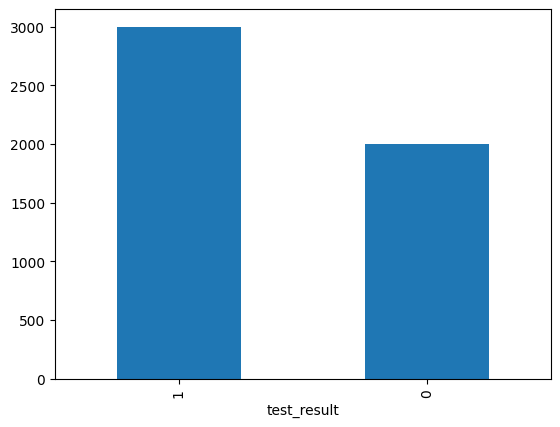

In [30]:
data['test_result'].value_counts().plot(kind='bar')

<Axes: xlabel='test_result', ylabel='age'>

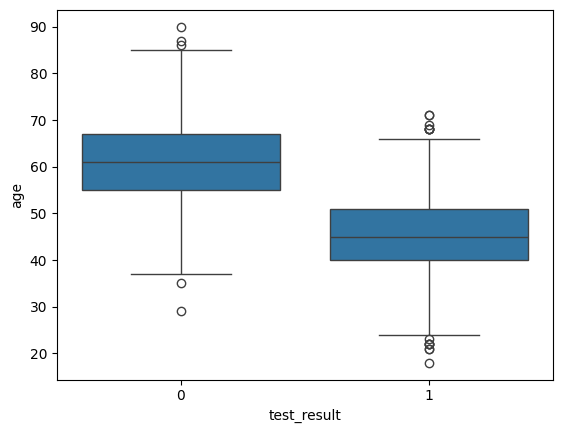

In [31]:
sns.boxplot(x='test_result', y="age", data=data)

<Axes: xlabel='age', ylabel='physical_score'>

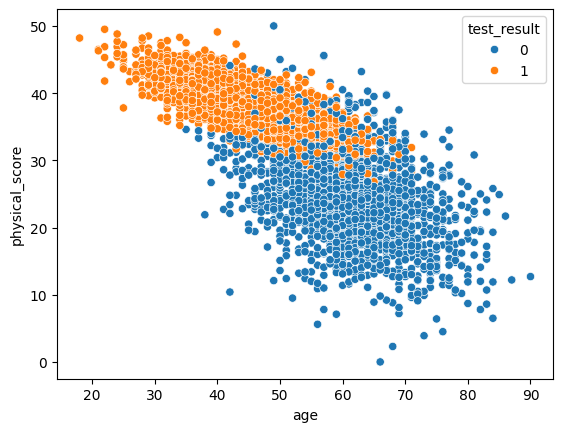

In [32]:
sns.scatterplot(x='age', y='physical_score', data=data, hue='test_result')

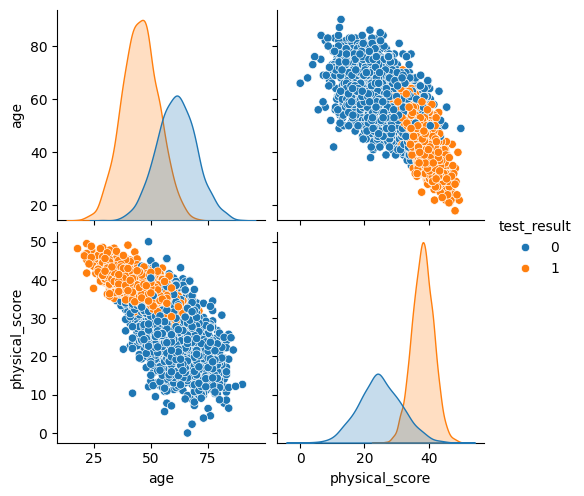

In [33]:
sns.pairplot(data, hue='test_result')

<Axes: >

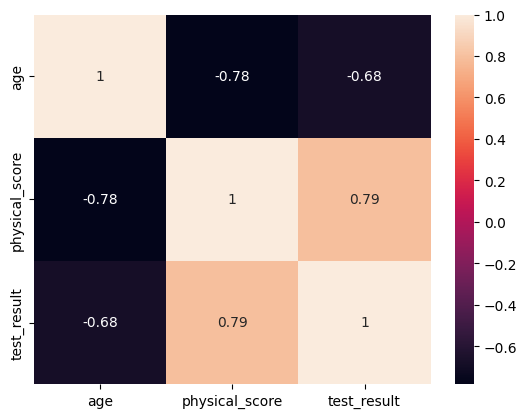

In [34]:
sns.heatmap(data.corr(), annot=True)

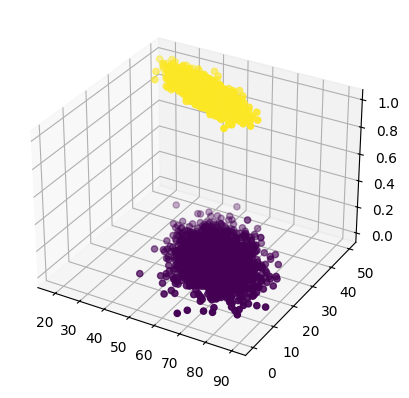

In [35]:
from mpl_toolkits.mplot3d import Axes3D
from torch import classes
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data['age'], data['physical_score'],
           data['test_result'], c=data['test_result'], cmap='viridis')

In [36]:
X = data.drop("test_result", axis=1)
y = data["test_result"]

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

In [38]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

help(LogisticRegression)

Help on class LogisticRegression in module sklearn.linear_model._logistic:

class LogisticRegression(sklearn.linear_model._base.LinearClassifierMixin, sklearn.linear_model._base.SparseCoefMixin, sklearn.base.BaseEstimator)
 |  LogisticRegression(
 |      penalty='l2',
 |      *,
 |      dual=False,
 |      tol=0.0001,
 |      C=1.0,
 |      fit_intercept=True,
 |      intercept_scaling=1,
 |      class_weight=None,
 |      random_state=None,
 |      solver='lbfgs',
 |      max_iter=100,
 |      multi_class='deprecated',
 |      verbose=0,
 |      warm_start=False,
 |      n_jobs=None,
 |      l1_ratio=None
 |  )
 |
 |  Logistic Regression (aka logit, MaxEnt) classifier.
 |
 |  This class implements regularized logistic regression using the
 |  'liblinear' library, 'newton-cg', 'sag', 'saga' and 'lbfgs' solvers. **Note
 |  that regularization is applied by default**. It can handle both dense
 |  and sparse input. Use C-ordered arrays or CSR matrices containing 64-bit
 |  floats for opti

In [39]:
model.fit(scaled_X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [40]:
model.coef_

array([[-0.91805986,  3.67035625]])

In [41]:
y_pred = model.predict(scaled_X_test)
y_pred_prob = model.predict_proba(scaled_X_test)

y_pred

array([1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1,
       1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0,

In [42]:
y_pred_prob

array([[0.03531052, 0.96468948],
       [0.98051197, 0.01948803],
       [0.03176642, 0.96823358],
       ...,
       [0.13624263, 0.86375737],
       [0.15067552, 0.84932448],
       [0.10158957, 0.89841043]], shape=(1000, 2))

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
y_pred = model.predict(scaled_X_test)

accuracy_score(y_test, y_pred)

0.897

In [44]:
confusion_matrix(y_test, y_pred)

array([[326,  58],
       [ 45, 571]])

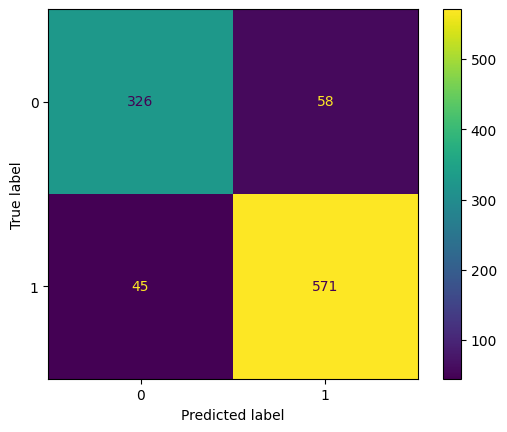

In [50]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(model, scaled_X_test, y_test)

plt.show()

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.85      0.86       384
           1       0.91      0.93      0.92       616

    accuracy                           0.90      1000
   macro avg       0.89      0.89      0.89      1000
weighted avg       0.90      0.90      0.90      1000



In [ ]:
from sklearn.metrics import precision_score, recall_score

precision_score(y_test, y_pred)

0.9077901430842608

In [ ]:
recall_score(y_test, y_pred)

0.926948051948052

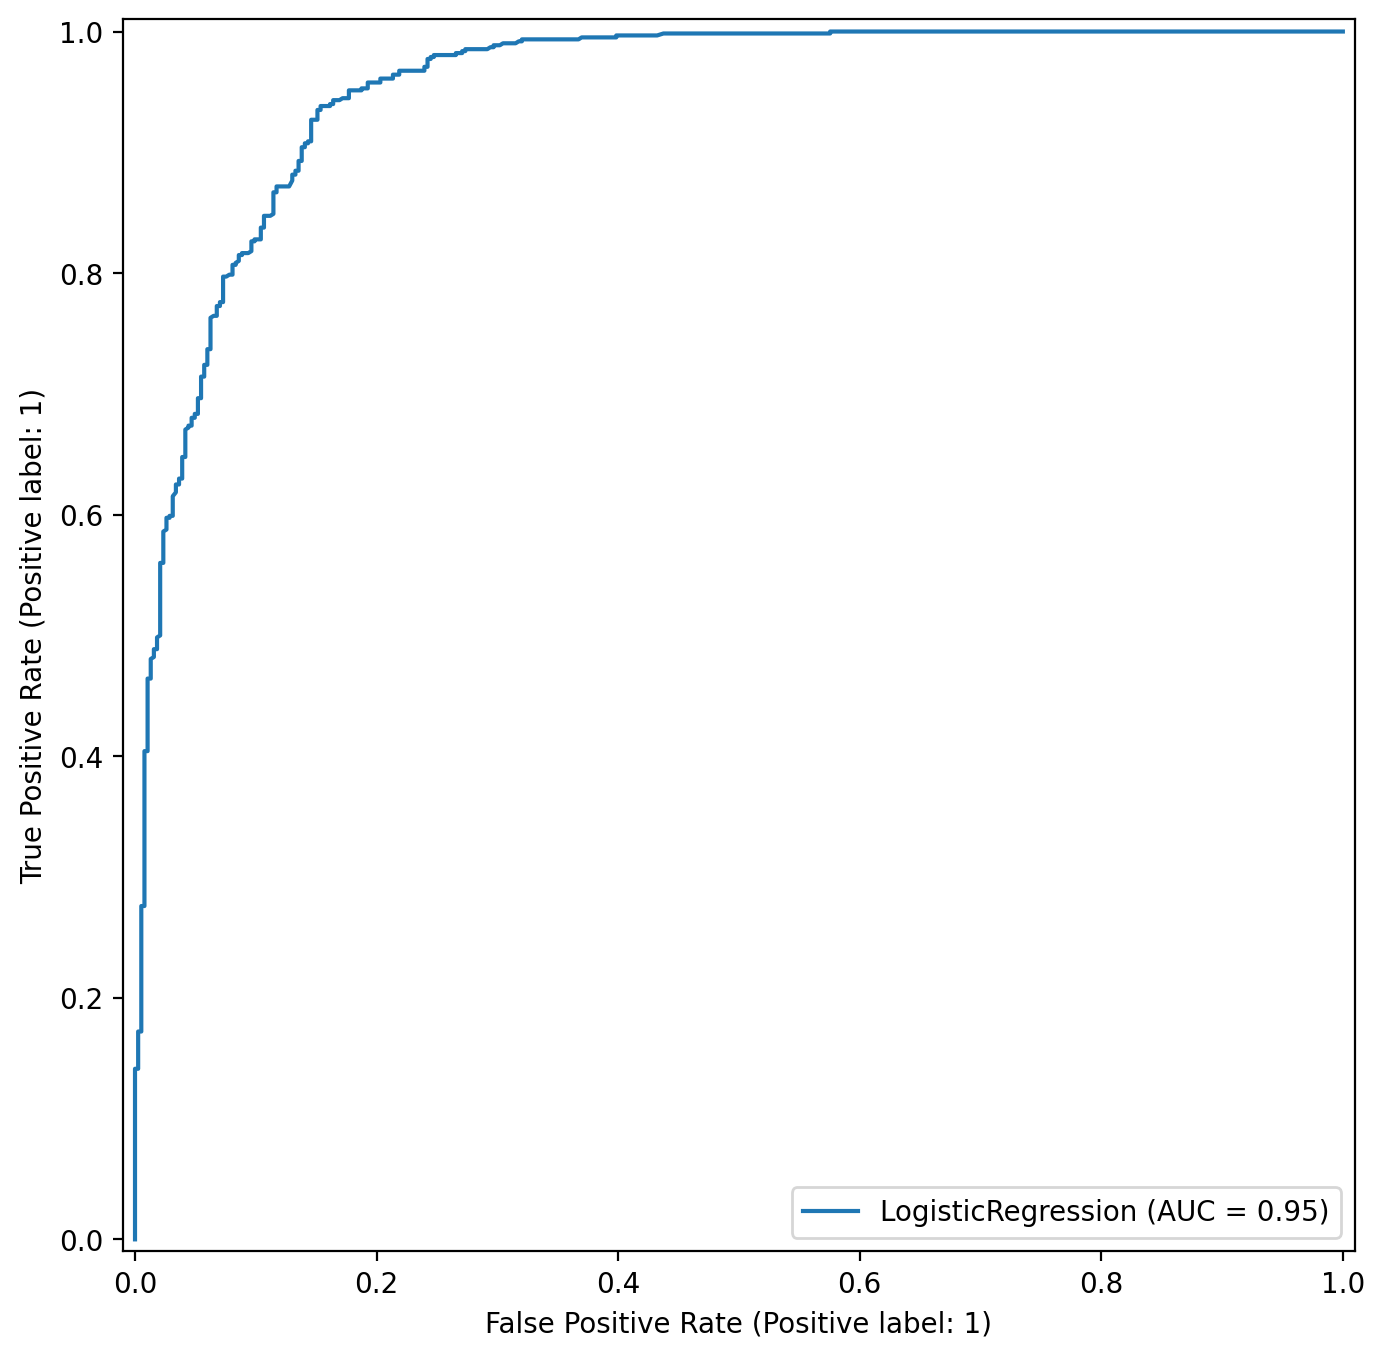

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay
fig, ax = plt.subplots(figsize=(12, 8), dpi=200)
RocCurveDisplay.from_estimator(model, scaled_X_test, y_test, ax=ax)

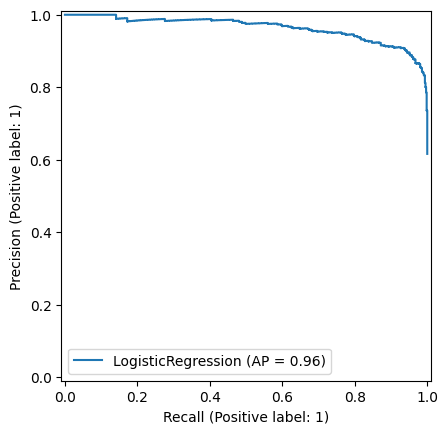

In [ ]:
PrecisionRecallDisplay.from_estimator(
    model, scaled_X_test, y_test, ax=ax).plot()

In [62]:
model.predict_proba(scaled_X_test)[0]

array([0.03531052, 0.96468948])